## Visualizations for Federal Tax Revenue
This notebook creates the following figures for visualizing federal tax revenue and effective tax rates
- Effective tax rates by income group, broken down into tax type, for a given fiscal year
    - Income groups: Lowest, Second, Middle, Fourth, and Highest Quintiles, 81st-90th, 91st-95th, and 96th-99th Percentiiles, and Top 1%
    - Tax Types: Individual Income, Payroll, Corporate Income, and Excise
    - Labels overall effective rate for each income group
- Sources of tax revenue, as a share/percentage of total tax revenue, for a given fiscal year
    - Sources: Individual Income, Corporate Income, Social Insurance and Retirement, Excise, and Other
    - Can be shown as a donut chart or a pie chart 
- Sources of tax revenue, as a share/perecntage of total tax revenue, over time
    - Sources: Individual Income, Corporate Income, Social Insurance and Retirement, Excise, and Other
    - Shows time series as a stacked plot
- Sources of tax revenue, in billions of USD, over time
    - Sources: Individual Income, Corporate Income, Social Insurance and Retirement, Excise, and Other
    - Shows time series as a stacked plot

The figures described above are created using data from the following sources: 
- Office of Management and Budget (OMB) Historical Tables
    - Table 2.1: Receipts by Source (Amount)
    - Table 2.2: Receipts by Source (Percent)
- Congressional Budget Office (CBO) Special Report
    - Effective Federal Tax Rates (by Income Group)
    - Supplemental data for a specific CBO report from November 2022, *The Distribution of Household Income, 2019*. (linked here - www.cbo.gov/publication/58353)
    - Data is originally from CBO, but the CBO website frequently blocks auto download requests, so this data is pulled instead from Tax Policy Center (TPC)
- Bureau of Labor Statistic (BLS) and Federal Reserve (FRED)
    - CPI data used to adjust tax revenue amount for inflation 

#### Download and Clean Data

In [14]:
# import data cleaning functions from data_download_and_clean.py
import data_download_and_clean as dat

# download, clean, and save data
data = dat.download_omb_tables()

# receipts by source amount
df_2_1 = data['table_2_1']
df_2_1_clean = dat.clean_omb_dataframe(df_2_1)

dat.save_data_csv(df_2_1_clean, 'receipts_by_source_amount_nominal') 

# adjust for inflation (express in 2017 dollars)
df_2_1_clean_real = dat.adjust_for_inflation(df_2_1_clean, 2017)

dat.save_data_csv(df_2_1_clean_real, 'receipts_by_source_amount_real')


# receipts by source percentage
df_2_2 = data['table_2_2']
df_2_2_clean = dat.clean_omb_dataframe(df_2_2)

dat.save_data_csv(df_2_2_clean, 'receipts_by_source_percent')


# effective tax rates
df_tax_rates = dat.download_tpc_table()
df_tax_rates_clean = dat.clean_tpc_dataframe(df_tax_rates)

dat.save_data_csv(df_tax_rates_clean, 'avg_effective_tax_rates')

URL: https://www.whitehouse.gov/wp-content/uploads/2025/06/BUDGET-2026-HIST.xlsx
Successfully loaded Table 2.1
Shape: (95, 15)
Successfully loaded Table 2.2
Shape: (92, 15)

Cleaning data...
Cleaned df shape: (91, 11)
Columns in cleaned df: ['Fiscal Year', 'Individual Income Taxes', 'Corporation Income Taxes', 'Social Insurance and Retirement Receipts Total', 'Social Insurance and Retirement Receipts On - Budget', 'Social Insurance and Retirement Receipts Off - Budget', 'Excise Taxes', 'Other', 'Total Receipts Total', 'Total Receipts On - Budget', 'Total Receipts Off - Budget']
Years: 1934 to 2024
Saved cleaned data to data/receipts_by_source_amount_nominal.csv
Downloaded CPI data for years 1947 - 2025
CPI data available from 1947 to 2025
Dropped 13 years withouth CPI data
Created inflation adjusted df with all values in 2017 dollars.
Years included: 1947 - 2024
Saved cleaned data to data/receipts_by_source_amount_real.csv

Cleaning data...
Cleaned df shape: (91, 11)
Columns in cleaned

#### Create Figures
Note: functions require a figure style and output directory as arguments, and some require a fiscal year

Creating effective tax rate charts for FY1971...
Error: No data available for fiscal year 1971
Available years: 1979 - 2020
Figure saved to figures\revenue_donut_fy1971.png


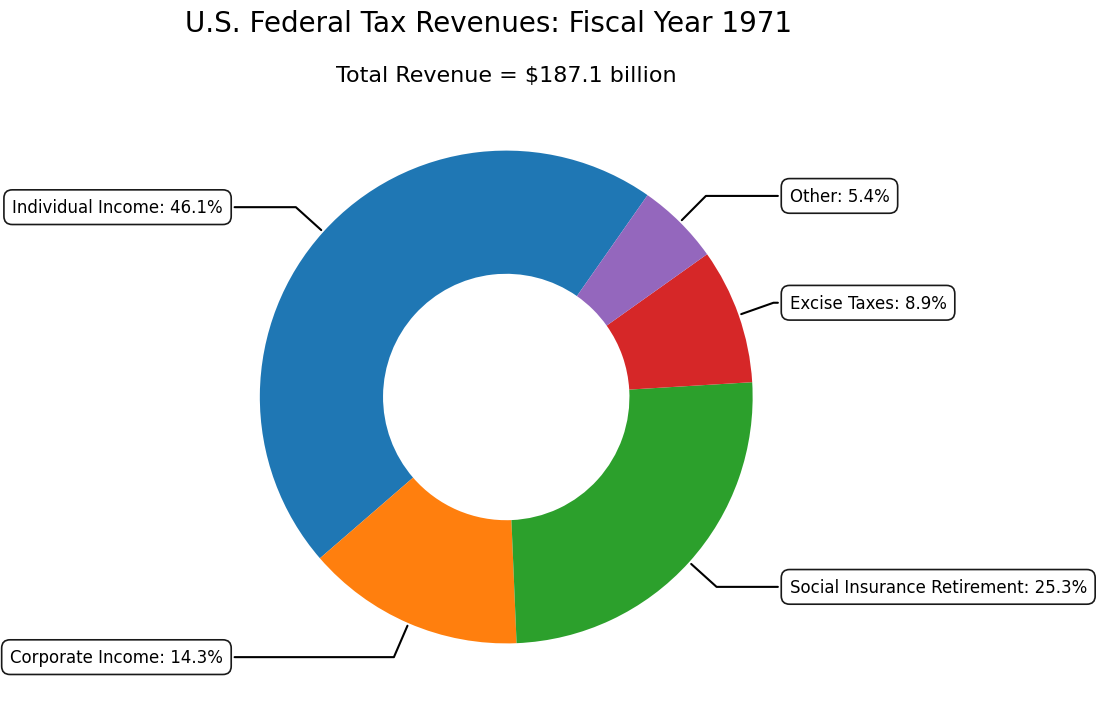

Figure saved to figures\revenue_pie_fy1971.png


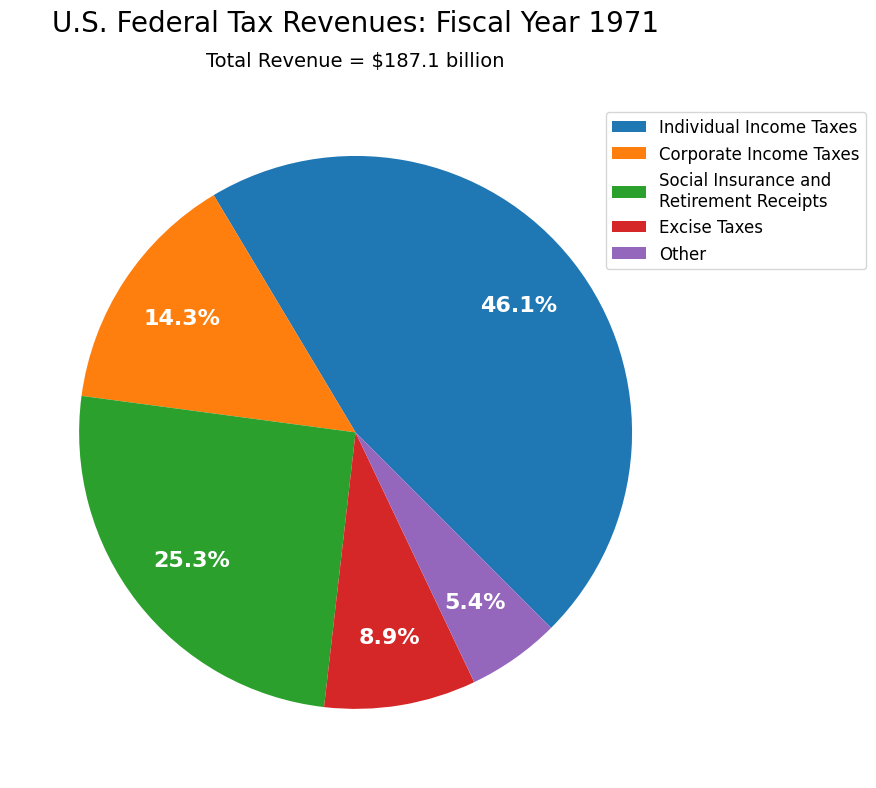

Figure saved to figures\revenue_share_hist_start1950.png


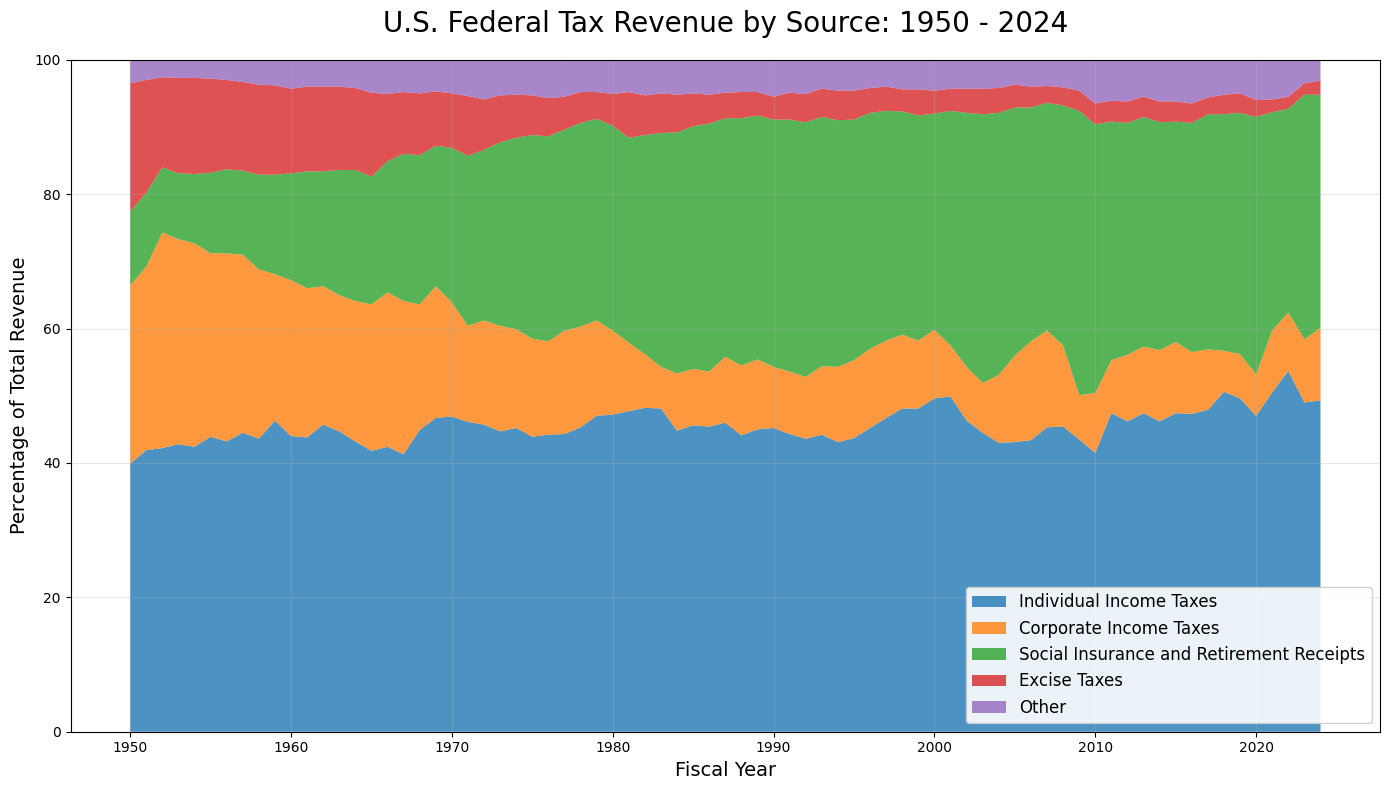

Figure saved to figures\revenue_hist_real_start1950.png


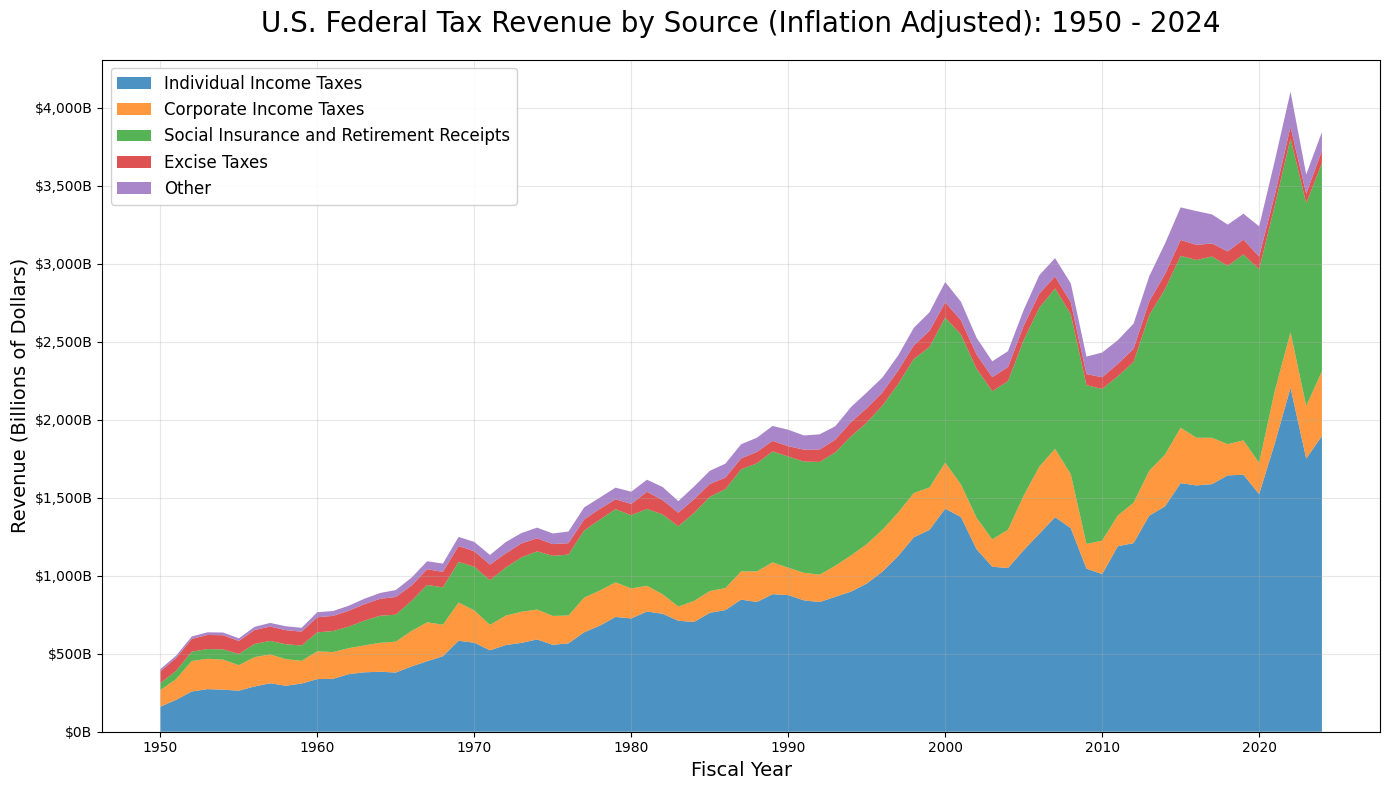

Figure saved to figures\revenue_hist_nominal_start1950.png


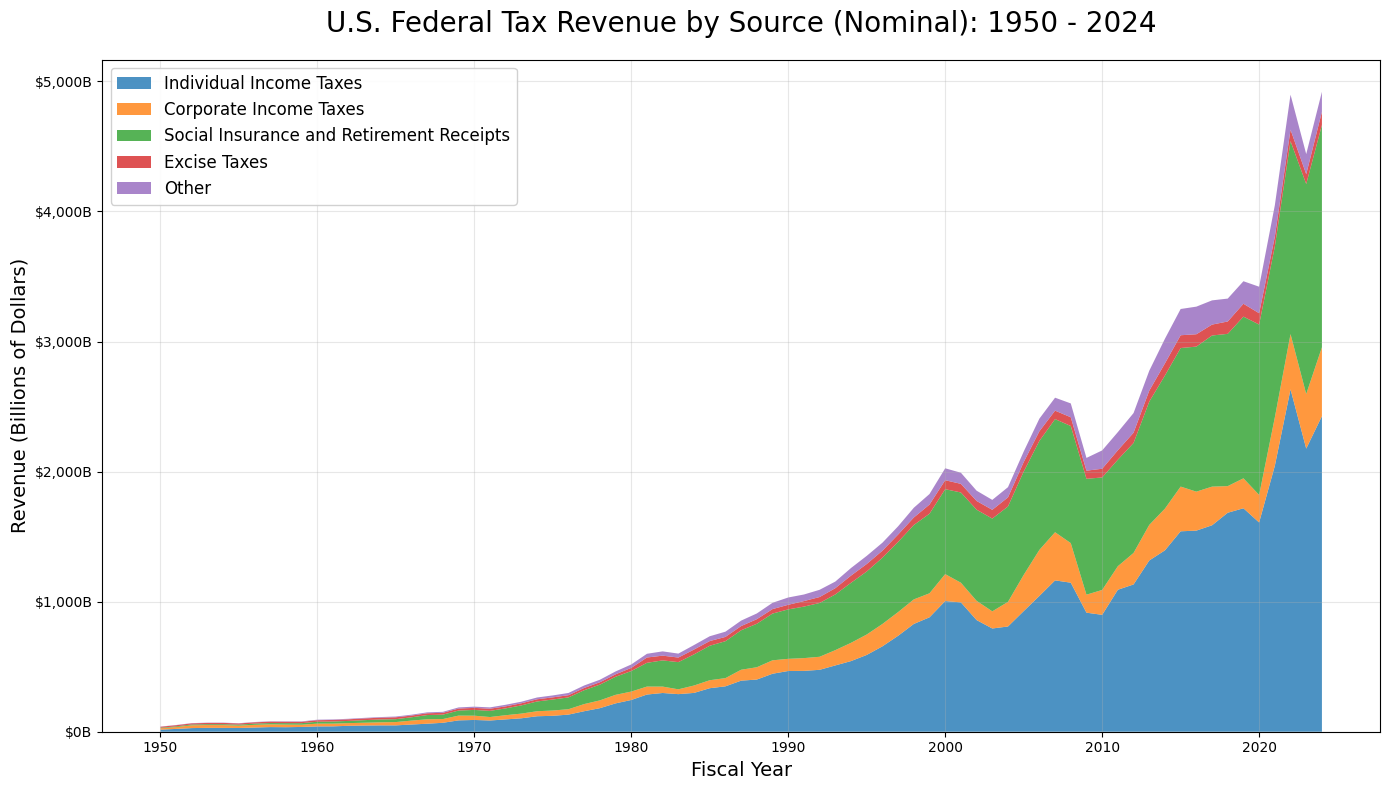

In [17]:
# import functions for creating figures from creating_figures.py
import creating_figures as fig

# set style and output directory for figures 
style = 'default'
output_dir = 'figures'

# set fiscal year
fiscal_year=1971

# set time series start year (match nominal and real time series)
start_year=1950

fig.effective_rates_chart(data_file='data/avg_effective_tax_rates.csv', fiscal_year=fiscal_year, style=style, output_dir=output_dir)

fig.revenue_donut_chart(data_file='data/receipts_by_source_amount_nominal.csv', fiscal_year=fiscal_year, style=style, output_dir=output_dir)

fig.revenue_pie_chart(data_file='data/receipts_by_source_amount_nominal.csv',fiscal_year=fiscal_year,style=style,output_dir=output_dir)

fig.revenue_share_hist(data_file='data/receipts_by_source_percent.csv', start_year=start_year, style=style, output_dir=output_dir)

fig.revenue_hist(data_file='data/receipts_by_source_amount_real.csv', start_year=start_year, style=style, output_dir=output_dir, real=True)

fig.revenue_hist(data_file='data/receipts_by_source_amount_nominal.csv', start_year=start_year, style=style, output_dir=output_dir, real=False)